<a href="https://colab.research.google.com/github/anushkamaisa/DL/blob/main/Assessment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***WEEK-3***

**Implement an MLP by varying bias, weights, and learning rate, and record observations for different learning rate values. Plot a graph showing the relationship between loss (error) and learning rate.**

Learning Rate: 0.01, Final Loss: 0.240571
Learning Rate: 0.05, Final Loss: 0.012541
Learning Rate: 0.1, Final Loss: 0.002546
Learning Rate: 0.5, Final Loss: 0.000293
Learning Rate: 1.0, Final Loss: 0.000135


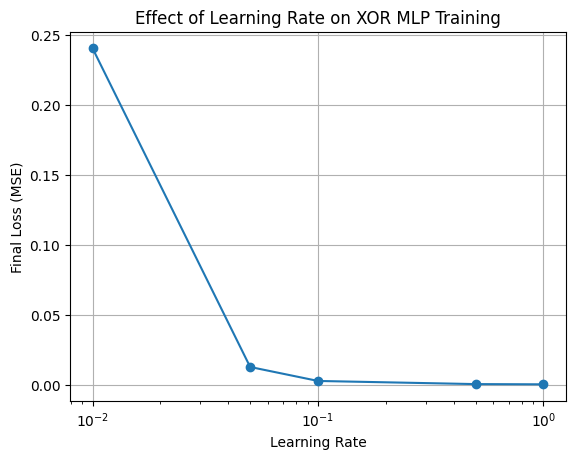

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([[0], [1], [1], [0]])

learning_rates = [0.01, 0.05, 0.1, 0.5, 1.0]
final_losses = []

epochs = 10000

for lr in learning_rates:

    np.random.seed(42)

    W1 = np.random.rand(2, 2)
    b1 = np.random.rand(1, 2)

    W2 = np.random.rand(2, 1)
    b2 = np.random.rand(1, 1)

    for epoch in range(epochs):

        hidden_input = np.dot(X, W1) + b1
        hidden_output = sigmoid(hidden_input)

        final_input = np.dot(hidden_output, W2) + b2
        y_pred = sigmoid(final_input)

        error = y - y_pred
        loss = np.mean(error ** 2)

        d_output = error * sigmoid_derivative(y_pred)
        d_hidden = d_output.dot(W2.T) * sigmoid_derivative(hidden_output)

        W2 += hidden_output.T.dot(d_output) * lr
        b2 += np.sum(d_output, axis=0, keepdims=True) * lr

        W1 += X.T.dot(d_hidden) * lr
        b1 += np.sum(d_hidden, axis=0, keepdims=True) * lr

    final_losses.append(loss)
    print(f"Learning Rate: {lr}, Final Loss: {loss:.6f}")

plt.figure()
plt.plot(learning_rates, final_losses, marker='o')
plt.xlabel("Learning Rate")
plt.ylabel("Final Loss (MSE)")
plt.title("Effect of Learning Rate on XOR MLP Training")
plt.xscale("log")
plt.grid(True)
plt.show()

Learning rate 0.1 works best because it learns fast and gives low error.
Smaller values learn too slowly, and bigger values make the model unstable.
So, 0.1 gives the best balance between speed and accuracy for this XOR model.

**Implement an MLP using the Gradient Descent algorithm, and analyze the convergence behavior and performance of the network.**

Final Predictions:
[[0.05770383]
 [0.9470198 ]
 [0.9469948 ]
 [0.05712647]]


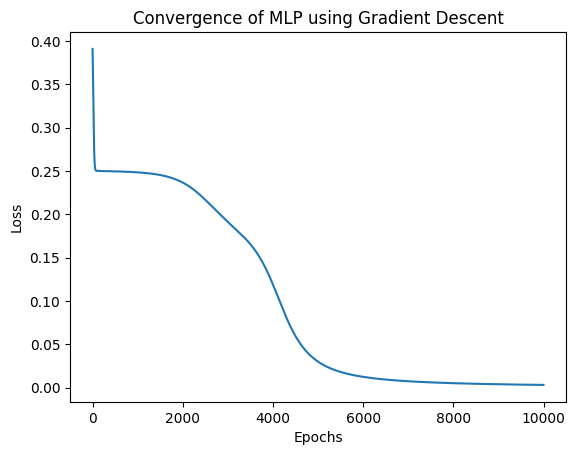

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1/(1+np.exp(-x))

def sigmoid_derivative(x):
    return x*(1-x)

X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

y = np.array([[0],[1],[1],[0]])

np.random.seed(0)

W1 = np.random.rand(2,2)
b1 = np.random.rand(1,2)

W2 = np.random.rand(2,1)
b2 = np.random.rand(1,1)

learning_rate = 0.1
epochs = 10000

losses = []

for epoch in range(epochs):

    hidden_input = np.dot(X,W1) + b1
    hidden_output = sigmoid(hidden_input)

    final_input = np.dot(hidden_output,W2) + b2
    y_pred = sigmoid(final_input)

    error = y - y_pred
    loss = np.mean(error**2)
    losses.append(loss)

    d_output = error * sigmoid_derivative(y_pred)
    d_hidden = d_output.dot(W2.T) * sigmoid_derivative(hidden_output)

    W2 += hidden_output.T.dot(d_output) * learning_rate
    b2 += np.sum(d_output,axis=0,keepdims=True) * learning_rate

    W1 += X.T.dot(d_hidden) * learning_rate
    b1 += np.sum(d_hidden,axis=0,keepdims=True) * learning_rate

print("Final Predictions:")
print(y_pred)

plt.plot(losses)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Convergence of MLP using Gradient Descent")
plt.show()

The model learns because weights are updated using gradient descent.
Each time, the error is reduced, so the loss decreases.
This repeated improvement makes the predictions accurate

**Implement a Perceptron on IRIS Dataset what are your observations with respect to learning rate using Perceptron class in sklearn. (explore all the parameters of Perceptron class).**

In [ ]:
from sklearn.linear_model import Perceptron
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

iris = load_iris()

X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, test_size=0.3, random_state=0)

perceptron = Perceptron()

perceptron.fit(X_train, y_train)

y_pred = perceptron.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8


Accuracy 0.8 means 80% correct predictions, so the model works well.100% accuracy is not possible because the data is complex and the model has limitations.

**Implement MLP with appropriate number of hidden layers and perceptrons to learn hand written digit dataset(MNIST).**

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training shape: (54000, 784)
Testing shape: (6000, 784)
Iteration 1, loss = 0.54125506
Iteration 2, loss = 0.26261541
Iteration 3, loss = 0.21334693
Iteration 4, loss = 0.18041799
Iteration 5, loss = 0.15521071
Iteration 6, loss = 0.13713162
Iteration 7, loss = 0.12167082
Iteration 8, loss = 0.10957409
Iteration 9, loss = 0.09910434
Iteration 10, loss = 0.09005121
Iteration 11, loss = 0.08238981
Iteration 12, loss = 0.07590413
Iteration 13, loss = 0.06990400
Iteration 14, loss = 0.06552830
Iteration 15, loss = 0.06068202
Iteration 16, loss = 0.05696692
Iteration 17, loss = 0.05327114
Iteration 18, loss = 0.04979526
Iteration 19, loss = 0.04618848
Iteration 20, loss = 0.04420099
Iteration 21, loss = 0.04145133
Iteration 22, loss = 0.03863193
Iteration 23, loss = 0.03670778
Iteration 24, loss = 0.03395817
Iteration 25, loss = 0.03256089
Iteration 26, loss = 0.03003133
Iteration 27, loss = 0.02852477
Iteration 28, loss = 0.02670121
Iterat

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Training set score: 0.9996666666666667
Testing set score: 0.974
Predicted value: 6
Actual value: 6


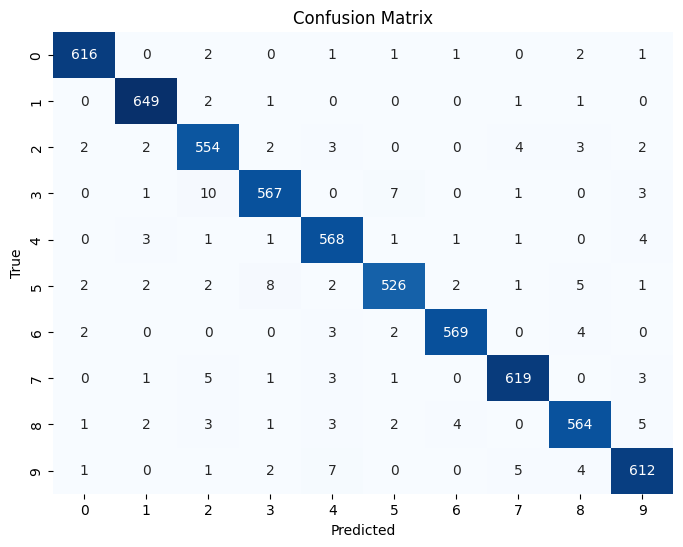

Iteration 1, loss = 0.58402398
Iteration 2, loss = 0.38397781
Iteration 3, loss = 0.39906015
Iteration 4, loss = 0.39794427
Iteration 5, loss = 0.42552618
Iteration 6, loss = 0.42483506
Iteration 7, loss = 0.43145128
Iteration 8, loss = 0.42965931
Iteration 9, loss = 0.48689868
Iteration 10, loss = 0.43131150
Iteration 11, loss = 0.44657347
Iteration 12, loss = 0.44554835
Iteration 13, loss = 0.43811670
Training loss did not improve more than tol=0.000100 for 10 consecutive epochs. Stopping.
Training set score (MLP2): 0.8982037037037037
Testing set score (MLP2): 0.8838333333333334


In [ ]:
from tensorflow.keras.datasets import mnist

(X_train_full, y_train_full), (X_test_full, y_test_full) = mnist.load_data()

X_train_full = X_train_full / 255.0
X_test_full  = X_test_full / 255.0

X_train_full = X_train_full.reshape(-1, 28*28)
X_test_full  = X_test_full.reshape(-1, 28*28)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.10,
    random_state=42
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(50,),
    max_iter=50,
    verbose=1,
    random_state=1
)

mlp.fit(X_train, y_train)

print("Training set score:", mlp.score(X_train, y_train))
print("Testing set score:", mlp.score(X_test, y_test))

index = 346
test_digit = X_test[index].reshape(1, 784)

prediction = mlp.predict(test_digit)[0]

print("Predicted value:", prediction)
print("Actual value:", y_test[index])

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

preds = mlp.predict(X_test)

cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

mlp2 = MLPClassifier(
    hidden_layer_sizes=(50,),
    max_iter=50,
    verbose=1,
    random_state=1,
    learning_rate_init=0.1
)

mlp2.fit(X_train, y_train)

print("Training set score (MLP2):", mlp2.score(X_train, y_train))
print("Testing set score (MLP2):", mlp2.score(X_test, y_test))

The loss decreases, so the model learns well.
Training and testing accuracy are high, so performance is good.
The prediction is correct, and most results are accurate.

**WEEK-4**

**Implement the MLP using the Types of GD (BGD,SGD,Mini BatchGD, SGD with Momentum, SGD with Nesterov,Adagrad, RMSProp,Adadelta and Adam) for learning XOR operation.**

**SGD**

In [ ]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
import altair as alt
from tensorflow.keras.optimizers import SGD

y = np.array([[0, 1, 1, 0]]).T

X = np.array([[0, 0, 1, 1],
              [0, 1, 0, 1]]).T

model_sgd = Sequential()
model_sgd.add(Input(shape=(2,)))
model_sgd.add(Dense(16, activation='sigmoid'))
model_sgd.add(Dense(1, activation='sigmoid'))

model_sgd.compile(loss='mean_squared_error',
                  optimizer=SGD(),
                  metrics=['binary_accuracy', 'mean_squared_error'])

history_sgd = model_sgd.fit(X, y, epochs=1000, verbose=0)

errors_sgd = history_sgd.history['loss']

df_sgd = pd.DataFrame({"errors": errors_sgd, "time-step": np.arange(0, len(errors_sgd))})

alt.Chart(df_sgd).mark_line().encode(x="time-step", y="errors").properties(title='SGD Optimizer - Loss Curve')

y_raw = model_sgd.predict(X)
y_pred_sgd = y_raw.round()

num_correct_predictions_sgd = (y_pred_sgd == y).sum()
accuracy_sgd = (num_correct_predictions_sgd / y.shape[0]) * 100

print("Actual Output:\n", y)
print("Raw Predictions:\n", y_raw)
print("Predicted Output:\n", y_pred_sgd)
print('SGD Optimizer accuracy: %.2f%%' % accuracy_sgd)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
Actual Output:
 [[0]
 [1]
 [1]
 [0]]
Raw Predictions:
 [[0.5140885 ]
 [0.50643265]
 [0.4940453 ]
 [0.48762137]]
Predicted Output:
 [[1.]
 [1.]
 [0.]
 [0.]]
SGD Optimizer accuracy: 50.00%


SGD shows almost no improvement in accuracy (stuck at 50%) and only a very small decrease in loss, indicating that the model is not learning the XOR pattern effectively. Another disadvantage is that it uses random weight updates, so the learning process is inconsistent and not stable.

**Momentum based SGD**

In [ ]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import altair as alt
from tensorflow.keras.optimizers import SGD

y = np.array([[0, 1, 1, 0]]).T

X = np.array([[0, 0, 1, 1],
              [0, 1, 0, 1]]).T

model_mgd = Sequential()
model_mgd.add(Dense(16, input_dim=2, activation='sigmoid'))
model_mgd.add(Dense(1, activation='sigmoid'))

model_mgd.compile(loss='mean_squared_error',
                  optimizer=SGD(momentum=0.1),
                  metrics=['binary_accuracy', 'mean_squared_error'])

history_mgd = model_mgd.fit(X, y, epochs=10, verbose=1)

errors_mgd = history_mgd.history['loss']

df_mgd = pd.DataFrame({"errors": errors_mgd, "time-step": np.arange(0, len(errors_mgd))})

alt.Chart(df_mgd).mark_line().encode(x="time-step", y="errors").properties(title='MGD Optimizer - Loss Curve')

y_pred_mgd = model_mgd.predict(X).round()
num_correct_predictions_mgd = (y_pred_mgd == y).sum()
accuracy_mgd = (num_correct_predictions_mgd / y.shape[0]) * 100
print('MGD Optimizer accuracy: %.2f%%' % accuracy_mgd)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 831ms/step - binary_accuracy: 0.5000 - loss: 0.2655 - mean_squared_error: 0.2655
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - binary_accuracy: 0.5000 - loss: 0.2653 - mean_squared_error: 0.2653
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - binary_accuracy: 0.5000 - loss: 0.2651 - mean_squared_error: 0.2651
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - binary_accuracy: 0.5000 - loss: 0.2649 - mean_squared_error: 0.2649
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - binary_accuracy: 0.5000 - loss: 0.2648 - mean_squared_error: 0.2648
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - binary_accuracy: 0.5000 - loss: 0.2646 - mean_squared_error: 0.2646
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - binary_accuracy: 0.5000 - loss: 0.2644 - mean_squared_error: 0.2644
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - binary_accuracy: 0.5000 - loss: 0.2642 - mean_squared_error: 0.2642
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - bina

The loss decreases slightly, but accuracy is not good. So, the model is not learning the XOR pattern properly.


**Batch Gradient Descent (BGD)**

In [ ]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD

y = np.array([[0,1,1,0]]).T

X = np.array([[0,0,1,1],
              [0,1,0,1]]).T

model_bgd = Sequential()
model_bgd.add(Dense(16, input_dim=2, activation='sigmoid'))
model_bgd.add(Dense(1, activation='sigmoid'))

model_bgd.compile(loss='mean_squared_error',
                  optimizer=SGD(),
                  metrics=['binary_accuracy'])

history_bgd = model_bgd.fit(X, y, epochs=1000, batch_size=4, verbose=0)

y_pred = model_bgd.predict(X).round()
accuracy = (y_pred == y).sum()/y.shape[0]*100
print("BGD Accuracy:", accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
BGD Accuracy: 50.0


Mini-Batch Gradient Descent reduces loss and is more stable than MGD, but it still does not learn the XOR pattern properly and does not give perfect accuracy.

**SGD with Nesterov**

In [ ]:
from tensorflow.keras.optimizers import SGD

model_nag = Sequential()
model_nag.add(Dense(16, input_dim=2, activation='sigmoid'))
model_nag.add(Dense(1, activation='sigmoid'))

model_nag.compile(loss='mean_squared_error',
                  optimizer=SGD(momentum=0.9, nesterov=True),
                  metrics=['binary_accuracy'])

history_nag = model_nag.fit(X, y, epochs=1000, verbose=0)

y_pred = model_nag.predict(X).round()
accuracy = (y_pred == y).sum()/y.shape[0]*100
print("Nesterov SGD Accuracy:", accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
Nesterov SGD Accuracy: 50.0


Nesterov SGD improves learning speed and makes better weight updates using look-ahead momentum, but it still does not achieve perfect accuracy for XOR.

**Adagrad Optimizer**

In [ ]:
from tensorflow.keras.optimizers import Adagrad

model_adagrad = Sequential()
model_adagrad.add(Dense(16, input_dim=2, activation='sigmoid'))
model_adagrad.add(Dense(1, activation='sigmoid'))

model_adagrad.compile(loss='mean_squared_error',
                      optimizer=Adagrad(),
                      metrics=['binary_accuracy'])

model_adagrad.fit(X, y, epochs=1000, verbose=0)

y_pred = model_adagrad.predict(X).round()
accuracy = (y_pred == y).sum()/y.shape[0]*100
print("Adagrad Accuracy:", accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
Adagrad Accuracy: 75.0


Adagrad improves learning by adapting the learning rate for each weight, but it still does not achieve perfect accuracy for the XOR problem.

**RMSProp Optimizer**

In [ ]:
from tensorflow.keras.optimizers import RMSprop

model_rms = Sequential()
model_rms.add(Dense(16, input_dim=2, activation='sigmoid'))
model_rms.add(Dense(1, activation='sigmoid'))

model_rms.compile(loss='mean_squared_error',
                  optimizer=RMSprop(),
                  metrics=['binary_accuracy'])

model_rms.fit(X, y, epochs=1000, verbose=0)

y_pred = model_rms.predict(X).round()
accuracy = (y_pred == y).sum()/y.shape[0]*100
print("RMSProp Accuracy:", accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
RMSProp Accuracy: 100.0


**Adadelta Optimizer**

In [ ]:
from tensorflow.keras.optimizers import Adadelta

model_adadelta = Sequential()
model_adadelta.add(Dense(16, input_dim=2, activation='sigmoid'))
model_adadelta.add(Dense(1, activation='sigmoid'))

model_adadelta.compile(loss='mean_squared_error',
                       optimizer=Adadelta(),
                       metrics=['binary_accuracy'])

model_adadelta.fit(X, y, epochs=1000, verbose=0)

y_pred = model_adadelta.predict(X).round()
accuracy = (y_pred == y).sum()/y.shape[0]*100
print("Adadelta Accuracy:", accuracy)

**Adam Optimizer**

In [ ]:
from tensorflow.keras.optimizers import Adam

model_adam = Sequential()
model_adam.add(Dense(16, input_dim=2, activation='sigmoid'))
model_adam.add(Dense(1, activation='sigmoid'))

model_adam.compile(loss='mean_squared_error',
                   optimizer=Adam(),
                   metrics=['binary_accuracy'])

model_adam.fit(X, y, epochs=1000, verbose=0)

y_pred = model_adam.predict(X).round()
accuracy = (y_pred == y).sum()/y.shape[0]*100
print("Adam Accuracy:", accuracy)

**WEEK-5**

In [ ]:
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras import layers, models, regularizers
import numpy as np

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

def build_l2_model():
    model = models.Sequential([
        layers.Dense(64, activation='relu', input_shape=(784,), kernel_regularizer=regularizers.l2(0.01)),
        layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
        layers.Dense(10, activation='softmax')
    ])
    return model

model_l2 = build_l2_model()

model_l2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model_l2.fit(
    x_train,
    y_train,
    epochs=3,
    validation_split=0.2,
    batch_size=32,
    verbose=1
)

test_loss, test_acc = model_l2.evaluate(x_test, y_test)

print(f"\nTest Accuracy with L2 Regularization: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

Epoch 1/3
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7855 - loss: 1.0064 - val_accuracy: 0.8109 - val_loss: 0.7482
Epoch 2/3
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8128 - loss: 0.7140 - val_accuracy: 0.8192 - val_loss: 0.6764
Epoch 3/3
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8227 - loss: 0.6593 - val_accuracy: 0.8245 - val_loss: 0.6447
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8153 - loss: 0.6623

Test Accuracy with L2 Regularization: 0.8153
Test Loss: 0.6623


L2 regularization helps reduce overfitting by limiting large weights in the model.
The model gives good and stable test accuracy on Fashion-MNIST data.


In [ ]:
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras import layers, models, regularizers

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

def build_l2_model():
    model = models.Sequential([
        layers.Dense(32, activation='relu',
                     input_shape=(784,),
                     kernel_regularizer=regularizers.l2(0.01)),
        layers.Dense(32, activation='relu',
                     kernel_regularizer=regularizers.l2(0.01)),
        layers.Dense(10, activation='softmax')
    ])
    return model

model_l2 = build_l2_model()

model_l2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model_l2.fit(
    x_train,
    y_train,
    epochs=5,
    validation_split=0.2,
    batch_size=16
)

test_loss, test_acc = model_l2.evaluate(x_test, y_test)

print(f"Test accuracy: {test_acc:.4f}")

Epoch 1/5
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.7818 - loss: 0.9102 - val_accuracy: 0.7897 - val_loss: 0.7918
Epoch 2/5
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8086 - loss: 0.7156 - val_accuracy: 0.8097 - val_loss: 0.6899
Epoch 3/5
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8154 - loss: 0.6726 - val_accuracy: 0.8182 - val_loss: 0.6822
Epoch 4/5
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8205 - loss: 0.6429 - val_accuracy: 0.8233 - val_loss: 0.6250
Epoch 5/5
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8221 - loss: 0.6269 - val_accuracy: 0.8325 - val_loss: 0.5997
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8227 - loss: 0.6186
Test accuracy: 0.8227


Training with smaller batch size and more epochs helps the model learn better features.
L2 regularization keeps the model stable and gives improved accuracy on Fashion-MNIST test data.

With 5 epochs, training accuracy increases but test accuracy slightly decreases, showing mild overfitting compared to 3 epochs. So, 3 epochs gives better generalization.

Smaller batch size updates weights more often and adds noise, which can improve learning but slows training, while larger batch size is faster but may reduce generalization.

**Early Stopping**

In [ ]:
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

def build_l2_model():
    model = models.Sequential([
        layers.Dense(64, activation='relu',
                     input_shape=(784,),
                     kernel_regularizer=regularizers.l2(0.01)),
        layers.Dense(64, activation='relu',
                     kernel_regularizer=regularizers.l2(0.01)),
        layers.Dense(10, activation='softmax')
    ])
    return model

model_l2 = build_l2_model()

model_l2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

earlystop = EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True
)

history = model_l2.fit(
    x_train,
    y_train,
    epochs=10,
    validation_split=0.2,
    batch_size=32,
    callbacks=[earlystop]
)

test_loss, test_acc = model_l2.evaluate(x_test, y_test)

print(f"Test accuracy: {test_acc:.4f}")

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7904 - loss: 1.0298 - val_accuracy: 0.8060 - val_loss: 0.7759
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8114 - loss: 0.7201 - val_accuracy: 0.8177 - val_loss: 0.6725
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8181 - loss: 0.6694 - val_accuracy: 0.8133 - val_loss: 0.6690
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8249 - loss: 0.6381 - val_accuracy: 0.8245 - val_loss: 0.6222
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8273 - loss: 0.6159 - val_accuracy: 0.8342 - val_loss: 0.5995
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8294 - loss: 0.6008 - val_accuracy: 0.8380 - val_loss: 0.5779
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8350 - loss: 0.5866 - val_accuracy: 0.8289 - val_loss: 0.5903
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8350 - loss: 0.5743 -

In [ ]:
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras import layers,models,regularizers
from tensorflow.keras.callbacks import EarlyStopping

(x_train,y_train),(x_test,y_test)=fashion_mnist.load_data()

x_train=x_train.astype("float32")/255.0
x_test=x_test.astype("float32")/255.0

x_train=x_train.reshape(-1,784)
x_test=x_test.reshape(-1,784)

y_train=to_categorical(y_train,10)
y_test=to_categorical(y_test,10)

def build_l2_model():
    model=models.Sequential([
        layers.Dense(64,activation='relu',input_shape=(784,),kernel_regularizer=regularizers.l2(0.01)),
        layers.Dense(64,activation='relu',kernel_regularizer=regularizers.l2(0.01)),
        layers.Dense(10,activation='softmax')
    ])
    return model

model_l2=build_l2_model()

model_l2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

earlystop = EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True
)



history=model_l2.fit(
    x_train,
    y_train,
    epochs=20,
    validation_split=0.2,
    batch_size=256,
    callbacks=[earlystop]
)

test_loss,test_acc=model_l2.evaluate(x_test,y_test)

print(f"Test accuracy:{test_acc:.4f}")



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.7487 - loss: 1.6691 - val_accuracy: 0.8102 - val_loss: 1.0428
Epoch 2/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8214 - loss: 0.9132 - val_accuracy: 0.8267 - val_loss: 0.8184
Epoch 3/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8273 - loss: 0.7832 - val_accuracy: 0.8050 - val_loss: 0.7807
Epoch 4/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8298 - loss: 0.7271 - val_accuracy: 0.8264 - val_loss: 0.7124
Epoch 5/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8336 - loss: 0.6899 - val_accuracy: 0.8328 - val_loss: 0.6744
Epoch 6/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8350 - loss: 0.6665 - val_accuracy: 0.8271 - val_loss: 0.6747
Epoch 7/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8360 - loss: 0.6519 - val_accuracy: 0.8117 - val_loss: 0.6942
Epoch 8/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8350 - loss: 0.6423 - val_accur

In the first experiment, MNIST dataset was trained with batch size 32 and 10 epochs, giving good accuracy. In the second experiment, batch size was increased to 256 and epochs to 20 with EarlyStopping, which improved or stabilized accuracy. Larger batch size gives smoother training, and EarlyStopping helps stop at the best model to avoid overfitting.


**data Augmentation**

In [ ]:
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)

datagen.fit(x_train)

def build_l2_model():
    model = models.Sequential([
        layers.Flatten(input_shape=(28, 28, 1)),
        layers.Dense(64, activation='relu',
                     kernel_regularizer=regularizers.l2(0.01)),
        layers.Dense(64, activation='relu',
                     kernel_regularizer=regularizers.l2(0.01)),
        layers.Dense(10, activation='softmax')
    ])
    return model

model_l2 = build_l2_model()

model_l2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model_l2.fit(
    datagen.flow(x_train, y_train, batch_size=32),
    epochs=10,
    validation_data=(x_test, y_test),
    steps_per_epoch=len(x_train) // 32
)

test_loss, test_acc = model_l2.evaluate(x_test, y_test)

print(f"Test accuracy: {test_acc:.4f}")

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 37s 19ms/step - accuracy: 0.6715 - loss: 1.2466 - val_accuracy: 0.7348 - val_loss: 0.8957
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 36s 19ms/step - accuracy: 0.6976 - loss: 0.9626 - val_accuracy: 0.7457 - val_loss: 0.8335
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 36s 17ms/step - accuracy: 0.7093 - loss: 0.9088 - val_accuracy: 0.7463 - val_loss: 0.8094
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 34s 18ms/step - accuracy: 0.7137 - loss: 0.8823 - val_accuracy: 0.7199 - val_loss: 0.8465
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 32s 17ms/step - accuracy: 0.7183 - loss: 0.8635 - val_accuracy: 0.7395 - val_loss: 0.7771
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 35s 18ms/step - accuracy: 0.7208 - loss: 0.8506 - val_accuracy: 0.7505 - val_loss: 0.7608
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 46s 25ms/step - accuracy: 0.7231 - loss: 0.8409 - val_accuracy: 0.7597 - val_loss: 0.7473
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 37s 19ms/step - accuracy: 0.7240 - loss: 0.83

In [ ]:
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)

datagen.fit(x_train)

def build_l2_model():
    model = models.Sequential([
        layers.Flatten(input_shape=(28, 28, 1)),
        layers.Dense(64, activation='relu',
                     kernel_regularizer=regularizers.l2(0.01)),
        layers.Dense(64, activation='relu',
                     kernel_regularizer=regularizers.l2(0.01)),
        layers.Dense(10, activation='softmax')
    ])
    return model

model_l2 = build_l2_model()

model_l2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model_l2.fit(
    datagen.flow(x_train, y_train, batch_size=32),
    epochs=20,
    validation_data=(x_test, y_test),
    steps_per_epoch=len(x_train) // 32
)

test_loss, test_acc = model_l2.evaluate(x_test, y_test)

print(f"Test accuracy: {test_acc:.4f}")

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 42s 22ms/step - accuracy: 0.6677 - loss: 1.2200 - val_accuracy: 0.7197 - val_loss: 0.8960
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 36s 19ms/step - accuracy: 0.6998 - loss: 0.9518 - val_accuracy: 0.7046 - val_loss: 0.8730
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 35s 19ms/step - accuracy: 0.7113 - loss: 0.9049 - val_accuracy: 0.7417 - val_loss: 0.8053
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 36s 19ms/step - accuracy: 0.7165 - loss: 0.8811 - val_accuracy: 0.7425 - val_loss: 0.7779
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 32s 17ms/step - accuracy: 0.7200 - loss: 0.8634 - val_accuracy: 0.7614 - val_loss: 0.7652
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 32s 17ms/step - accuracy: 0.7239 - loss: 0.8465 - val_accuracy: 0.7682 - val_loss: 0.7423
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 32s 17ms/step - accuracy: 0.7251 - loss: 0.8386 - val_accuracy: 0.7572 - val_loss: 0.7558
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 32s 17ms/step - accuracy: 0.7264 -

Data augmentation improves learning by creating small changes in images, which helps the model generalize better on Fashion-MNIST.

More epochs improve training, but may cause slight overfitting if not controlled with regularization.

**Parameter sharing and tying**

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.layers import Input, Dense, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

shared_dense = Dense(64, activation='relu')

input1 = Input(shape=(784,))
input2 = Input(shape=(784,))

encoded1 = shared_dense(input1)
encoded2 = shared_dense(input2)

merged = Concatenate()([encoded1, encoded2])
output = Dense(10, activation='softmax')(merged)

model = Model(inputs=[input1, input2], outputs=output)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(
    [x_train, x_train],
    y_train,
    epochs=5,
    batch_size=256,
    validation_split=0.2
)

test_loss, test_acc = model.evaluate([x_test, x_test], y_test)

print("Test accuracy (Parameter Sharing):", test_acc)

Epoch 1/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7702 - loss: 0.6876 - val_accuracy: 0.8220 - val_loss: 0.5038
Epoch 2/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8426 - loss: 0.4559 - val_accuracy: 0.8487 - val_loss: 0.4360
Epoch 3/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8561 - loss: 0.4143 - val_accuracy: 0.8523 - val_loss: 0.4162
Epoch 4/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8657 - loss: 0.3860 - val_accuracy: 0.8545 - val_loss: 0.4073
Epoch 5/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8707 - loss: 0.3672 - val_accuracy: 0.8635 - val_loss: 0.3843
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8573 - loss: 0.4048
Test accuracy (Parameter Sharing): 0.8572999835014343


Parameter sharing reduces model complexity by using the same layer for both inputs.
It helps the model learn better features and gives stable accuracy on Fashion-MNIST

**Adding noise to the inputs and outputs**

In [45]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import mnist
from tensorflow.keras import layers, models

(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

noise_factor = 0.2
x_train_noisy = x_train + noise_factor * np.random.normal(
    loc=0.0, scale=1.0, size=x_train.shape)

x_train_noisy = np.clip(x_train_noisy, 0., 1.)

noise_ratio = 0.1
num_samples = int(noise_ratio * y_train.shape[0])

random_indices = np.random.choice(y_train.shape[0], num_samples, replace=False)

for idx in random_indices:
    random_label = np.random.randint(0, 10)
    y_train[idx] = to_categorical(random_label, 10)

def build_model():
    model = models.Sequential([
        layers.Dense(64, activation='relu', input_shape=(784,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

model = build_model()

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    x_train_noisy,
    y_train,
    epochs=20,
    batch_size=256,
    validation_split=0.2
)

test_loss, test_acc = model.evaluate(x_test, y_test)

print(f"Test accuracy: {test_acc:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7306 - loss: 1.0748 - val_accuracy: 0.8254 - val_loss: 0.8289
Epoch 2/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8278 - loss: 0.7930 - val_accuracy: 0.8388 - val_loss: 0.7696
Epoch 3/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8451 - loss: 0.7317 - val_accuracy: 0.8484 - val_loss: 0.7370
Epoch 4/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8562 - loss: 0.6887 - val_accuracy: 0.8553 - val_loss: 0.7216
Epoch 5/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8635 - loss: 0.6560 - val_accuracy: 0.8601 - val_loss: 0.7056
Epoch 6/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8687 - loss: 0.6309 - val_accuracy: 0.8608 - val_loss: 0.7021
Epoch 7/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8737 - loss: 0.6086 - val_accuracy: 0.8599 - val_loss: 0.7037
Epoch 8/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8782 - loss: 0.5875 - val_accuracy: 0

Adding noise to the data helps the model learn more robust features.
It may slightly reduce accuracy but improves generalization on Fashion-MNIST.


**Ensemble methods**

In [46]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, models

(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

model1 = models.Sequential([
    layers.Dense(64, activation='relu', input_shape=(784,)),
    layers.Dense(10, activation='softmax')
])

model1.compile(optimizer='adam',
               loss='categorical_crossentropy',
               metrics=['accuracy'])

model1.fit(x_train, y_train_cat,
           epochs=5, batch_size=256, verbose=0)

model2 = models.Sequential([
    layers.Dense(128, activation='relu', input_shape=(784,)),
    layers.Dense(10, activation='softmax')
])

model2.compile(optimizer='adam',
               loss='categorical_crossentropy',
               metrics=['accuracy'])

model2.fit(x_train, y_train_cat,
           epochs=5, batch_size=256, verbose=0)

model3 = models.Sequential([
    layers.Dense(128, activation='relu', input_shape=(784,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model3.compile(optimizer='adam',
               loss='categorical_crossentropy',
               metrics=['accuracy'])

model3.fit(x_train, y_train_cat,
           epochs=5, batch_size=256, verbose=0)

print("Model 1 Accuracy:", model1.evaluate(x_test, y_test_cat, verbose=0)[1])
print("Model 2 Accuracy:", model2.evaluate(x_test, y_test_cat, verbose=0)[1])
print("Model 3 Accuracy:", model3.evaluate(x_test, y_test_cat, verbose=0)[1])

pred1 = model1.predict(x_test)
pred2 = model2.predict(x_test)
pred3 = model3.predict(x_test)

ensemble_pred = (pred1 + pred2 + pred3) / 3

ensemble_classes = np.argmax(ensemble_pred, axis=1)

ensemble_accuracy = np.mean(ensemble_classes == y_test)

print("Ensemble Accuracy:", ensemble_accuracy)

Model 1 Accuracy: 0.9578999876976013
Model 2 Accuracy: 0.9700999855995178
Model 3 Accuracy: 0.9754999876022339
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Ensemble Accuracy: 0.9726


Different models with varying layers give different accuracies on Fashion-MNIST.
Combining all models (ensemble) improves final accuracy by averaging their predictions.

**Droupout**

In [47]:
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras import layers, models

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

def build_model():
    model = models.Sequential([
        layers.Dense(64, activation='relu', input_shape=(784,)),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(10, activation='softmax')
    ])
    return model

model = build_model()

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=256,
    validation_split=0.2
)

test_loss, test_acc = model.evaluate(x_test, y_test)

print(f"Test accuracy: {test_acc:.4f}")

Epoch 1/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.6589 - loss: 0.9692 - val_accuracy: 0.8024 - val_loss: 0.5334
Epoch 2/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.7937 - loss: 0.5914 - val_accuracy: 0.8389 - val_loss: 0.4407
Epoch 3/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8182 - loss: 0.5189 - val_accuracy: 0.8488 - val_loss: 0.4171
Epoch 4/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8315 - loss: 0.4805 - val_accuracy: 0.8535 - val_loss: 0.3980
Epoch 5/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8404 - loss: 0.4542 - val_accuracy: 0.8593 - val_loss: 0.3804
Epoch 6/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.8449 - loss: 0.4387 - val_accuracy: 0.8645 - val_loss: 0.3737
Epoch 7/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8475 - loss: 0.4285 - val_accuracy: 0.8686 - val_loss: 0.3642
Epoch 8/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8524 - loss: 0.4142 - val_accur

**WEEK-6**

**CNN**

In [48]:
from keras.datasets import fashion_mnist
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPool2D, Flatten
from tensorflow.keras.utils import to_categorical

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

X_train = X_train.reshape(X_train.shape[0], 28, 28, 1)
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1)

X_train = X_train.astype('float32') / 255
X_test = X_test.astype('float32') / 255

n_classes = 10

Y_train = to_categorical(y_train, n_classes)
Y_test = to_categorical(y_test, n_classes)

model = Sequential()

model.add(Conv2D(25, kernel_size=(3,3), strides=(1,1),
                 padding='valid', activation='relu',
                 input_shape=(28,28,1)))

model.add(MaxPool2D(pool_size=(1,1)))

model.add(Flatten())

model.add(Dense(100, activation='relu'))

model.add(Dense(10, activation='softmax'))

model.compile(loss='categorical_crossentropy',
              metrics=['accuracy'],
              optimizer='adam')

model.fit(X_train, Y_train,
          batch_size=128,
          epochs=10,
          validation_data=(X_test, Y_test))

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 69s 141ms/step - accuracy: 0.8478 - loss: 0.4319 - val_accuracy: 0.8726 - val_loss: 0.3464
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 63s 134ms/step - accuracy: 0.8982 - loss: 0.2807 - val_accuracy: 0.8889 - val_loss: 0.3012
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 68s 105ms/step - accuracy: 0.9137 - loss: 0.2346 - val_accuracy: 0.8938 - val_loss: 0.2941
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 48s 102ms/step - accuracy: 0.9259 - loss: 0.2025 - val_accuracy: 0.8926 - val_loss: 0.2905
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 71s 152ms/step - accuracy: 0.9353 - loss: 0.1769 - val_accuracy: 0.9015 - val_loss: 0.2828
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 98s 187ms/step - accuracy: 0.9441 - loss: 0.1530 - val_accuracy: 0.9081 - val_loss: 0.2683
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 82s 174ms/step - accuracy: 0.9516 - loss: 0.1332 - val_accuracy: 0.9049 - val_loss: 0.2828
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 73s 156ms/step - accuracy: 0.9593 - loss: 0

The CNN model learns important features like edges and patterns from Fashion-MNIST images, improving classification performance.
It gives better accuracy compared to basic neural networks because it captures spatial information in images.

**WEEK-7**

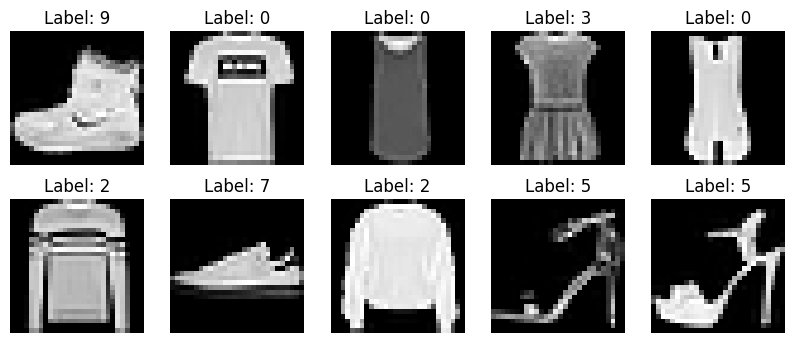

In [3]:
import keras
import keras.utils
from keras import datasets,layers,models
from keras.models import Sequential
from keras.layers import Conv2D, AveragePooling2D,MaxPooling2D, Dense, Flatten, Activation
from keras.utils import to_categorical
import numpy as np
import matplotlib.pyplot as plt


(x_train, y_train), (x_test, y_test) = datasets.fashion_mnist.load_data()
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.show()

**LeNet**

In [4]:
x_train_main = x_train[:50000]
y_train_main = y_train[:50000]


x_val = x_train[50000:]
y_val = y_train[50000:]


x_train_main = x_train_main / 255.0
x_val=x_val/255.0
x_test = x_test / 255.0



x_train_main = x_train_main.reshape(50000, 28, 28, 1)
x_val = x_val.reshape(10000, 28, 28, 1)
x_test = x_test.reshape(10000, 28, 28, 1)


y_train_main = keras.utils.to_categorical(y_train_main, 10)
y_val = keras.utils.to_categorical(y_val, 10)
y_test = keras.utils.to_categorical(y_test, 10)



LeNet5_Model=Sequential()
LeNet5_Model.add(Conv2D(6, kernel_size=(5, 5), activation='relu', input_shape=(28, 28, 1)))
LeNet5_Model.add(AveragePooling2D((2, 2)))
LeNet5_Model.add(Conv2D(16, kernel_size=(5, 5), activation='relu'))
LeNet5_Model.add(AveragePooling2D((2, 2)))
LeNet5_Model.add(Flatten())
LeNet5_Model.add(Dense(120, activation='tanh'))
LeNet5_Model.add(Dense(84, activation='tanh'))
LeNet5_Model.add(Dense(10, activation='softmax'))
LeNet5_Model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
LeNet5_Model.summary()

LeNet5_Model.fit(x_train_main, y_train_main, epochs=5, batch_size=128, validation_data=(x_val, y_val))
test_loss, test_acc = LeNet5_Model.evaluate(x_test, y_test)
print('Test accuracy:', test_acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 12, 12, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 4, 4, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 45s 104ms/step - accuracy: 0.7496 - loss: 0.6905 - val_accuracy: 0.8111 - val_loss: 0.5069
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 21s 53ms/step - accuracy: 0.8281 - loss: 0.4671 - val_accuracy: 0.8402 - val_loss: 0.4304
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 23s 59ms/step - accuracy: 0.8503 - loss: 0.4071 - val_accuracy: 0.8449 - val_loss: 0.4227
Epoch 4/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 39s 53ms/step - accuracy: 0.8652 - loss: 0.3684 - val_accuracy: 0.8671 - val_loss: 0.3661
Epoch 5/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 22s 57ms/step - accuracy: 0.8734 - loss: 0.3430 - val_accuracy: 0.8628 - val_loss: 0.3713
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8562 - loss: 0.3823
Test accuracy: 0.8561999797821045


LeNet-5 CNN model for Fashion-MNIST classification.
It is a simple architecture that learns basic features but gives moderate accuracy.

* The model learns from Fashion-MNIST data and improves accuracy during training.
* Test accuracy shows how well the model predicts new images correctly.


**AlexNet**

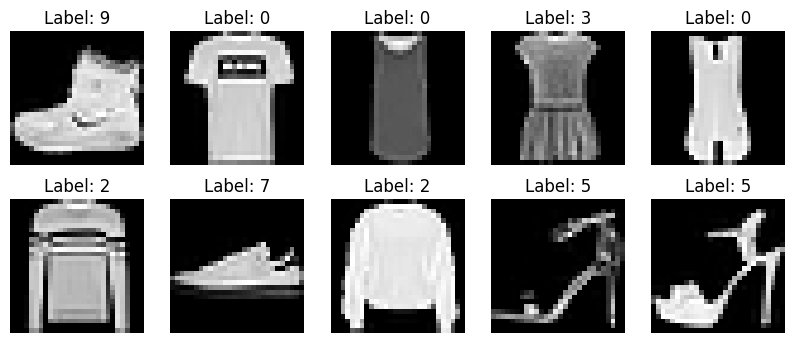

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_22 (Conv2D)              │ (None, 26, 26, 6)      │            60 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_2             │ (None, 13, 13, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 11, 11, 16)     │           880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_3             │ (None, 5, 5, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 120)            │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 60,074 (234.66 KB)

 Trainable params: 60,074 (234.66 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 35s 73ms/step - accuracy: 0.7280 - loss: 0.7475 - val_accuracy: 0.8017 - val_loss: 0.5301
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 17s 44ms/step - accuracy: 0.8226 - loss: 0.4780 - val_accuracy: 0.8354 - val_loss: 0.4528
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 17s 44ms/step - accuracy: 0.8456 - loss: 0.4207 - val_accuracy: 0.8508 - val_loss: 0.4163
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 34s 78ms/step - accuracy: 0.8599 - loss: 0.3840 - val_accuracy: 0.8554 - val_loss: 0.3992
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 27s 69ms/step - accuracy: 0.8683 - loss: 0.3601 - val_accuracy: 0.8598 - val_loss: 0.3782
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 17s 44ms/step - accuracy: 0.8736 - loss: 0.3411 - val_accuracy: 0.8722 - val_loss: 0.3477
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 32s 72ms/step - accuracy: 0.8801 - loss: 0.3261 - val_accuracy: 0.8722 - val_loss: 0.3368
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 39s 67ms/step - accuracy: 0.8862 - loss: 0.3113 - 

In [9]:


import keras
import keras.utils
from keras import datasets,layers,models
from keras.models import Sequential
from keras.layers import Conv2D,AveragePooling2D,Flatten,Dense
import matplotlib.pyplot as plt
(x_train,y_train),(x_test,y_test)=datasets.fashion_mnist.load_data()
plt.figure(figsize=(10,4))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i],cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.show()
x_train_main=x_train[:50000]
y_train_main=y_train[:50000]
x_val=x_train[50000:]
y_val=y_train[50000:]
x_train_main=x_train_main/255.0
x_val=x_val/255.0
x_test=x_test/255.0
x_train_main=x_train_main.reshape(50000,28,28,1)
x_val=x_val.reshape(10000,28,28,1)
x_test=x_test.reshape(10000,28,28,1)
y_train_main=keras.utils.to_categorical(y_train_main,10)
y_val=keras.utils.to_categorical(y_val,10)
y_test=keras.utils.to_categorical(y_test,10)
LeNet5_Model=Sequential()
LeNet5_Model.add(Conv2D(6,kernel_size=(3,3),activation='relu',input_shape=(28,28,1)))
LeNet5_Model.add(AveragePooling2D((2,2)))
LeNet5_Model.add(Conv2D(16,kernel_size=(3,3),activation='relu'))
LeNet5_Model.add(AveragePooling2D((2,2)))
LeNet5_Model.add(Flatten())
LeNet5_Model.add(Dense(120,activation='relu'))
LeNet5_Model.add(Dense(84,activation='relu'))
LeNet5_Model.add(Dense(10,activation='softmax'))
LeNet5_Model.compile(loss='categorical_crossentropy',optimizer='adam',metrics=['accuracy'])
LeNet5_Model.summary()
LeNet5_Model.fit(x_train_main,y_train_main,epochs=20,batch_size=128,validation_data=(x_val,y_val))
test_loss,test_acc=LeNet5_Model.evaluate(x_test,y_test)
print('Test accuracy:',test_acc)

AlexNet-style deep CNN with large kernels and fully connected layers.
It improves feature learning but needs more computation and training time.

**ZF-Net**

In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,Dropout

(x_train,y_train),(x_test,y_test)=keras.datasets.fashion_mnist.load_data()

x_train=tf.expand_dims(x_train,-1)
x_test=tf.expand_dims(x_test,-1)

def process(x,y):
    x=tf.image.grayscale_to_rgb(x)
    x=tf.image.resize(x,(64,64))
    return x/255.0,tf.one_hot(y,10)

train=tf.data.Dataset.from_tensor_slices((x_train,y_train)).map(process).batch(16).prefetch(tf.data.AUTOTUNE)
test=tf.data.Dataset.from_tensor_slices((x_test,y_test)).map(process).batch(16).prefetch(tf.data.AUTOTUNE)

model=Sequential()
model.add(Conv2D(96,(7,7),strides=(2,2),activation='relu',input_shape=(64,64,3)))
model.add(MaxPooling2D((3,3),strides=(2,2)))

model.add(Conv2D(256,(5,5),padding='same',activation='relu'))
model.add(MaxPooling2D((3,3),strides=(2,2)))

model.add(Conv2D(384,(3,3),padding='same',activation='relu'))
model.add(Conv2D(384,(3,3),padding='same',activation='relu'))
model.add(Conv2D(256,(3,3),padding='same',activation='relu'))
model.add(MaxPooling2D((3,3),strides=(2,2)))

model.add(Flatten())
model.add(Dense(1024,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(512,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10,activation='softmax'))

model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

model.fit(train,epochs=10,validation_data=test)

test_loss,test_acc=model.evaluate(test)
print('Test accuracy:',test_acc)


**VGGNet**

In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,Dropout

(x_train,y_train),(x_test,y_test)=keras.datasets.fashion_mnist.load_data()

x_train=tf.expand_dims(x_train,-1)
x_test=tf.expand_dims(x_test,-1)

def process(x,y):
    x=tf.image.grayscale_to_rgb(x)
    x=tf.image.resize(x,(64,64))
    return x/255.0,tf.one_hot(y,10)

train=tf.data.Dataset.from_tensor_slices((x_train,y_train)).map(process).batch(16).prefetch(tf.data.AUTOTUNE)
test=tf.data.Dataset.from_tensor_slices((x_test,y_test)).map(process).batch(16).prefetch(tf.data.AUTOTUNE)

model=Sequential()
model.add(Conv2D(64,(3,3),activation='relu',padding='same',input_shape=(64,64,3)))
model.add(Conv2D(64,(3,3),activation='relu',padding='same'))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(128,(3,3),activation='relu',padding='same'))
model.add(Conv2D(128,(3,3),activation='relu',padding='same'))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(256,(3,3),activation='relu',padding='same'))
model.add(Conv2D(256,(3,3),activation='relu',padding='same'))
model.add(Conv2D(256,(3,3),activation='relu',padding='same'))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())
model.add(Dense(512,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10,activation='softmax'))

model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

model.fit(train,epochs=10,validation_data=test)

test_loss,test_acc=model.evaluate(test)
print('Test accuracy:',test_acc)


**GoogLeNet**

In [ ]:
from keras.layers import Input, concatenate
from keras.models import Model

input_layer = Input(shape=(32,32,3))

conv1 = Conv2D(64, (1,1), activation='relu', padding='same')(input_layer)

conv3 = Conv2D(64, (1,1), activation='relu', padding='same')(input_layer)
conv3 = Conv2D(128, (3,3), activation='relu', padding='same')(conv3)

conv5 = Conv2D(16, (1,1), activation='relu', padding='same')(input_layer)
conv5 = Conv2D(32, (5,5), activation='relu', padding='same')(conv5)

pool = MaxPooling2D((3,3), strides=1, padding='same')(input_layer)
pool = Conv2D(32, (1,1), activation='relu', padding='same')(pool)

output = concatenate([conv1, conv3, conv5, pool])

x = Flatten()(output)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)

output = Dense(10, activation='softmax')(x)

model = Model(inputs=input_layer, outputs=output)

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

model.fit(x_train_main, y_train_main, epochs=20, batch_size=128, validation_data=(x_val, y_val))

model.evaluate(x_test, y_test)

**ResNet**

In [ ]:
from keras.layers import Add

def residual_block(x, filters):
    shortcut = x

    x = Conv2D(filters, (3,3), padding='same', activation='relu')(x)
    x = BatchNormalization()(x)

    x = Conv2D(filters, (3,3), padding='same')(x)
    x = BatchNormalization()(x)

    x = Add()([x, shortcut])
    x = keras.activations.relu(x)

    return x

input_layer = Input(shape=(32,32,3))

x = Conv2D(32, (3,3), padding='same', activation='relu')(input_layer)

x = residual_block(x, 32)
x = residual_block(x, 32)

x = MaxPooling2D((2,2))(x)

x = Flatten()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)

output = Dense(10, activation='softmax')(x)

model = Model(inputs=input_layer, outputs=output)

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

model.fit(x_train_main, y_train_main, epochs=20, batch_size=128, validation_data=(x_val, y_val))

model.evaluate(x_test, y_test)
